In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_excel("swiggy_data.xlsx")
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.shape

(197430, 10)

In [6]:
df.isnull().count()

State              197430
City               197430
Order Date         197430
Restaurant Name    197430
Location           197430
Category           197430
Dish Name          197430
Price (INR)        197430
Rating             197430
Rating Count       197430
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


## KPI's

### Total Sales

In [10]:
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR): ",round(total_sales,2)

Total Sales (INR):  53012505.77


### Average Rating

In [11]:
average_rating = df["Rating"].mean()
print("Average Rating: ",round(average_rating,2))

Average Rating:  4.34


### Average Order

In [13]:
average_order = df["Price (INR)"].mean()
print("Average Order: ",round(average_order,2))

Average Order:  268.51


### Rating Count

In [14]:
rating_count = df["Rating Count"].sum()
print("Total Rating: ",round(rating_count,2))

Total Rating:  5591574


### Total Order

In [15]:
total_order = len(df)
print("Total Order: ",round(total_order,2))

Total Order:  197430


## Charts Design

### Monthly Sales Trend

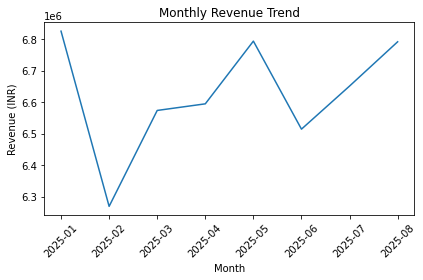

In [25]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("Year Month")["Price (INR)"].sum().reset_index()
plt.plot(monthly_revenue["Year Month"], monthly_revenue["Price (INR)"])
plt.xticks(rotation = 45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

### Daily Sales trend

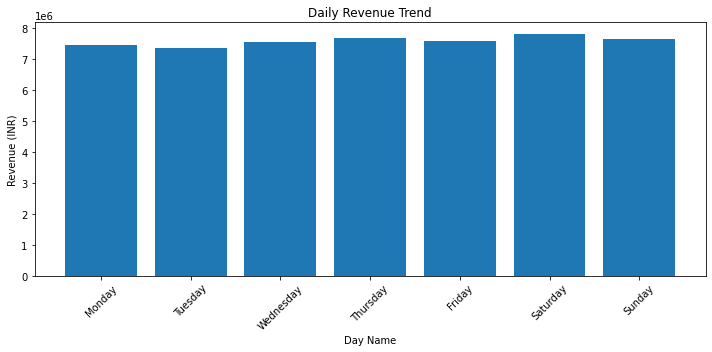

In [42]:
df["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()
daily_revenue = (df.groupby("DayName")["Price (INR)"]
                 .sum()
                 .reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
                )
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.xticks(rotation = 45)
plt.xlabel("Day Name")
plt.ylabel("Revenue (INR)")
plt.title("Daily Revenue Trend")
plt.tight_layout()
plt.show()


### Total Sales by Food Type

In [43]:
df["Dish Name"].unique()

array(['Butter Murukku-200gm', 'Badam Milk', 'Chow Chow Bath', ...,
       'Chilli cheese momo ', 'Veg Momos (8 Pc)', 'Soya Momo'],
      dtype=object)

In [45]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "briyani", "kabab", "kebab",
    "non-veg", "non veg"
]

df["food_category"] = np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)


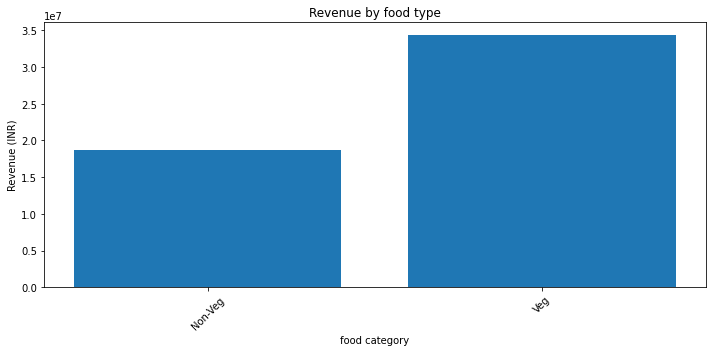

In [48]:
food_revenue = (
    df.groupby("food_category")["Price (INR)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(food_revenue["food_category"], food_revenue["Price (INR)"])
plt.xticks(rotation = 45)
plt.xlabel("food category")
plt.ylabel("Revenue (INR)")
plt.title("Revenue by food type")
plt.tight_layout()
plt.show()


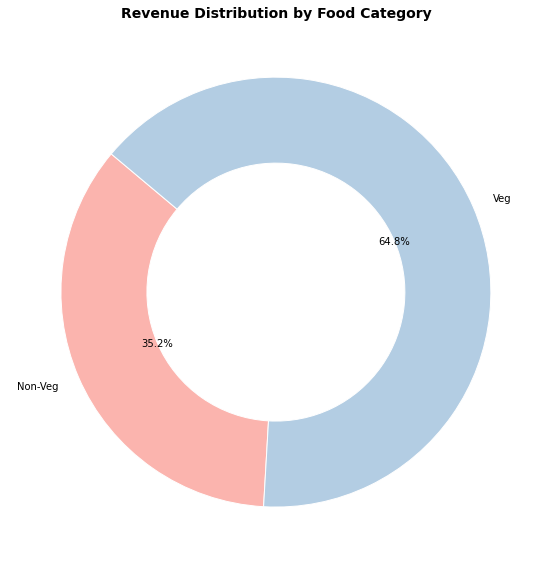

In [49]:
# Plot
plt.figure(figsize=(8, 8))

colors = plt.cm.Pastel1.colors  # nice soft colors

plt.pie(
    food_revenue["Price (INR)"],
    labels=food_revenue["food_category"],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}  # makes it donut
)

plt.title("Revenue Distribution by Food Category", fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [55]:
# Donut chart
fig = px.pie(
    food_revenue,
    names="food_category",
    values="Price (INR)",
    hole=0.5,  # donut effect
   # color_discrete_sequence=px.colors.sequential.Reds  # strong dark colors
)

# Layout customization
fig.update_traces(
    textinfo='percent+label',
    textfont_size=12,
    pull = [0.05,0]
)

fig.update_layout(
    title="Revenue Distribution by Food Category",
    title_x=0.5,
    #template="plotly_dark",  # dark background
    font=dict(size=13),
    margin = dict(t=60, b=40, l=40,r=40)
)

fig.show()

### Total Sales by State

In [58]:
fig = px.bar(
    df.groupby("State",as_index = False)["Price (INR)"].sum()
    .sort_values("Price (INR)", ascending = False),
    x = "Price (INR)",
    y = "State",
    orientation = "h",
    title = "Revenue by State (INR)"
)
fig.update_layout(height = 600, yaxis=dict(autorange="reversed"))
fig.show()

### Quarterly Performance Summary

In [61]:
df["order_date"] = pd.to_datetime(df["Order Date"])

df["Quarter"] = df["order_date"].dt.to_period("Q").astype(str)

In [62]:
quarterly_summary = df.groupby("Quarter").agg(
    Total_Sales=("Price (INR)", "sum"),
    Total_Orders=("Price (INR)", "count"),
    Avg_Rating=("Rating", "mean")
).reset_index()

In [67]:
quarterly_summary

,Quarter,Total_Sales,Total_Orders,Avg_Rating
0,2025Q1,19667821.77,73096,4.342643
1,2025Q2,19902256.59,74163,4.340011
2,2025Q3,13442427.41,50171,4.342359


In [66]:
import plotly.graph_objects as go

fig = go.Figure()

# Sales (Bar)
fig.add_trace(go.Bar(
    x=quarterly_summary["Quarter"],
    y=quarterly_summary["Total_Sales"],
    name="Total Sales",
))

# Orders (Line)
fig.add_trace(go.Scatter(
    x=quarterly_summary["Quarter"],
    y=quarterly_summary["Total_Orders"],
    mode="lines+markers",
    name="Total Orders",
    yaxis="y2"
))

# Ratings (Line)
fig.add_trace(go.Scatter(
    x=quarterly_summary["Quarter"],
    y=quarterly_summary["Avg_Rating"],
    mode="lines+markers",
    name="Avg Rating",
    yaxis="y3"
))

# Layout (Dark + Multiple Axes)
fig.update_layout(
    template="plotly_dark",
    title="Quarterly Performance Summary",
    title_x=0.5,

    yaxis=dict(title="Sales (INR)"),
    
    yaxis2=dict(
        title="Orders",
        overlaying="y",
        side="right"
    ),
    
    yaxis3=dict(
        #title="Rating",
        anchor="free",
        overlaying="y",
        side="right",
        position=0.95
    )
    
)

fig.show()

### TOP 5 Cities By Sales

In [68]:
city_sales = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .reset_index()
)

In [83]:
top5_cities = city_sales.sort_values(by="Price (INR)", ascending=False).head(5)

fig = px.bar(
    top5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales",
    color="City",
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5
)

fig.show()

### Weekly Trend Analysis

In [84]:
df["order_date"] = pd.to_datetime(df["Order Date"])

# Extract week
df["Week"] = df["order_date"].dt.to_period("W").astype(str)

In [85]:
weekly_sales = (
    df.groupby("Week")["Price (INR)"]
    .sum()
    .reset_index()
)

In [87]:
fig = px.line(
    weekly_sales,
    x="Week",
    y="Price (INR)",
    title="Weekly Sales Trend (Fluctuation Analysis)",
    markers=True
)

fig.update_layout(
    template="plotly_dark",
    title_x=0.5,
    xaxis_title="Week",
    yaxis_title="Sales (INR)"
)

fig.show()

In [89]:
weekly_sales["Moving_Avg"] = weekly_sales["Price (INR)"].rolling(3).mean()

import plotly.graph_objects as go

fig = go.Figure()

# Actual sales
fig.add_trace(go.Scatter(
    x=weekly_sales["Week"],
    y=weekly_sales["Price (INR)"],
    mode="lines+markers",
    name="Weekly Sales"
))

# Moving average
fig.add_trace(go.Scatter(
    x=weekly_sales["Week"],
    y=weekly_sales["Moving_Avg"],
    mode="lines",
    name="3-Week Avg"
))

fig.update_layout(
    template="plotly_dark",
    title="Weekly Sales with Trend Line",
    title_x=0.5
)
peak_value = weekly_sales["Price (INR)"].max()

fig.add_annotation(
    x=weekly_sales.loc[weekly_sales["Price (INR)"].idxmax(), "Week"],
    y=peak_value,
    text="Peak Sales 🚀",
    showarrow=True
)

fig.show()